# MinneApple YOLO Detection Analysis

This notebook analyzes a trained YOLO model on MinneApple using:
- Best weight: `results/01_minneapple_yolo_tradition_aug/Step_2_Train_and_Evaluate_BASELINE_MODEL/train_results/best.pt`
- Dataset properties: `results/01_minneapple_yolo_tradition_aug/Step_1_Load_and_Validate_Dataset/dataset_properties.json`

Outputs include:
- Dataset object statistics
- Miss rate and false positive rate
- Miss characteristics by object size
- Miss characteristics by lighting
- Miss characteristics by occlusion

In [13]:
# Cell 2: imports and paths
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

WEIGHT_PATH = Path('/home/khanh/Projects/DifficultyAgri/results/01_minneapple_yolo_tradition_aug/Step_2_Train_and_Evaluate_BASELINE_MODEL/train_results/best.pt')
DATASET_PROPERTIES_PATH = Path('/home/khanh/Projects/DifficultyAgri/results/01_minneapple_yolo_tradition_aug/Step_1_Load_and_Validate_Dataset/dataset_properties.json')

# Evaluation settings
IOU_THRESHOLD = 0.5
CONF_THRESHOLD = 0.35
MAX_DET = 300
MAX_IMAGES = None  # Set an integer (e.g., 200) for faster debug runs

print(f'Weight exists: {WEIGHT_PATH.exists()} -> {WEIGHT_PATH}')
print(f'Dataset properties exists: {DATASET_PROPERTIES_PATH.exists()} -> {DATASET_PROPERTIES_PATH}')

Weight exists: True -> /home/khanh/Projects/DifficultyAgri/results/01_minneapple_yolo_tradition_aug/Step_2_Train_and_Evaluate_BASELINE_MODEL/train_results/best.pt
Dataset properties exists: True -> /home/khanh/Projects/DifficultyAgri/results/01_minneapple_yolo_tradition_aug/Step_1_Load_and_Validate_Dataset/dataset_properties.json


In [14]:
# Cell 3: load dataset properties and define split directories
if not DATASET_PROPERTIES_PATH.exists():
    raise FileNotFoundError(f'Dataset properties file not found: {DATASET_PROPERTIES_PATH}')

with open(DATASET_PROPERTIES_PATH, 'r', encoding='utf-8') as f:
    dataset_properties = json.load(f)

def _as_path(value):
    if value is None:
        return None
    p = Path(value)
    return p if p.exists() else None

# Prefer explicit directories from dataset properties when available.
train_images_dir = _as_path(dataset_properties.get('train_images_dir'))
train_labels_dir = _as_path(dataset_properties.get('train_labels_dir'))
val_images_dir = _as_path(dataset_properties.get('val_images_dir'))
val_labels_dir = _as_path(dataset_properties.get('val_labels_dir'))
test_images_dir = _as_path(dataset_properties.get('test_images_dir'))
test_labels_dir = _as_path(dataset_properties.get('test_labels_dir'))

# Fallback: auto-discover a YOLO dataset root in common locations.
if any(p is None for p in [train_images_dir, train_labels_dir, val_images_dir, val_labels_dir, test_images_dir, test_labels_dir]):
    candidate_roots = [
        Path('/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo'),
        Path('/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format'),
    ]

    def _find_split_dirs(base_root: Path, split_name: str):
        image_candidates = [
            base_root / split_name / 'images',
            base_root / 'images' / split_name,
            base_root / split_name,
        ]
        label_candidates = [
            base_root / split_name / 'labels',
            base_root / 'labels' / split_name,
        ]
        images_dir = next((p for p in image_candidates if p.exists()), None)
        labels_dir = next((p for p in label_candidates if p.exists()), None)
        return labels_dir, images_dir

    for root in candidate_roots:
        if not root.exists():
            continue
        tr_l, tr_i = _find_split_dirs(root, 'train')
        va_l, va_i = _find_split_dirs(root, 'val')
        te_l, te_i = _find_split_dirs(root, 'test')
        if all(p is not None for p in [tr_l, tr_i, va_l, va_i, te_l, te_i]):
            train_labels_dir, train_images_dir = tr_l, tr_i
            val_labels_dir, val_images_dir = va_l, va_i
            test_labels_dir, test_images_dir = te_l, te_i
            break

required = [train_labels_dir, train_images_dir, val_labels_dir, val_images_dir, test_labels_dir, test_images_dir]
if any(p is None for p in required):
    raise FileNotFoundError('Unable to resolve train/val/test image and label directories.')

def categorize_object_by_size_coco(width, height, img_width=None, img_height=None):
    """COCO size categories by area in pixels: small<32^2, medium<96^2, else large."""
    if img_width is not None and img_height is not None:
        area_px = (width * img_width) * (height * img_height)
    else:
        area_px = width * height

    if area_px < 32 * 32:
        return 'small'
    if area_px < 96 * 96:
        return 'medium'
    return 'large'

print('Split directories loaded:')
print(f'- train: labels={train_labels_dir}, images={train_images_dir}')
print(f'- val:   labels={val_labels_dir}, images={val_images_dir}')
print(f'- test:  labels={test_labels_dir}, images={test_images_dir}')

Split directories loaded:
- train: labels=/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/train/labels, images=/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/train/images
- val:   labels=/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/val/labels, images=/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/val/images
- test:  labels=/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/test/labels, images=/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/test/images


In [15]:
def extract_object_sizes(labels_dir: Path, images_dir: Path):
    '''Extract bounding box sizes and categorize by COCO standards'''
    from PIL import Image
    
    sizes_px = []  # pixel areas
    sizes_cat = []  # COCO categories
    
    txt_files = sorted(labels_dir.glob('*.txt'))
    for label_path in txt_files:
        # Get corresponding image to read dimensions
        stem = label_path.stem
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
            candidate = images_dir / f"{stem}{ext}"
            if candidate.exists():
                img_path = candidate
                break
        
        # Get image dimensions
        if img_path and img_path.exists():
            try:
                img = Image.open(img_path)
                img_width, img_height = img.size
            except:
                img_width, img_height = None, None
        else:
            img_width, img_height = None, None
        
        with open(label_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) < 5:
                    continue
                # YOLO format: class x_center y_center width height (normalized)
                width = float(parts[3])
                height = float(parts[4])
                
                # Calculate area in pixels using actual image dimensions
                if img_width is not None and img_height is not None:
                    area_px = (width * img_width) * (height * img_height)
                else:
                    area_px = width * height  # fallback to normalized area
                
                sizes_px.append(area_px)
                cat = categorize_object_by_size_coco(width, height, img_width, img_height)
                sizes_cat.append(cat)
    
    return np.array(sizes_px, dtype=float), sizes_cat

# Analyze sizes for each split
for split_name, labels_dir, images_dir in [
    ('train', train_labels_dir, train_images_dir),
    ('val', val_labels_dir, val_images_dir),
    ('test', test_labels_dir, test_images_dir),
]:
    sizes_px, sizes_cat = extract_object_sizes(labels_dir, images_dir)
    
    if len(sizes_px) == 0:
        print(f'\n{split_name.upper()} split: No objects found')
        continue
    
    small_count = sizes_cat.count('small')
    medium_count = sizes_cat.count('medium')
    large_count = sizes_cat.count('large')
    
    print(f'\n{split_name.upper()} split:')
    print(f'  Total objects: {len(sizes_px)}')
    print(f'  Small (<1024 px²): {small_count} ({100*small_count/len(sizes_px):.1f}%)')
    print(f'  Medium (1024-9216 px²): {medium_count} ({100*medium_count/len(sizes_px):.1f}%)')
    print(f'  Large (≥9216 px²): {large_count} ({100*large_count/len(sizes_px):.1f}%)')
    print(f'  Area stats: min={sizes_px.min():.1f}, max={sizes_px.max():.1f}, mean={sizes_px.mean():.1f}')


TRAIN split:
  Total objects: 22815
  Small (<1024 px²): 16793 (73.6%)
  Medium (1024-9216 px²): 6022 (26.4%)
  Large (≥9216 px²): 0 (0.0%)
  Area stats: min=1.0, max=6525.0, mean=796.5

VAL split:
  Total objects: 5367
  Small (<1024 px²): 3894 (72.6%)
  Medium (1024-9216 px²): 1473 (27.4%)
  Large (≥9216 px²): 0 (0.0%)
  Area stats: min=20.0, max=6216.0, mean=816.4

TEST split:
  Total objects: 12285
  Small (<1024 px²): 6794 (55.3%)
  Medium (1024-9216 px²): 5480 (44.6%)
  Large (≥9216 px²): 11 (0.1%)
  Area stats: min=12.0, max=12544.0, mean=1128.9


In [16]:
# Cell 4: utility functions for matching and per-image diagnostics
def read_yolo_label_file(label_path: Path):
    boxes = []
    classes = []
    if not label_path.exists():
        return np.zeros((0, 4), dtype=float), np.zeros((0,), dtype=int)

    with open(label_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            cls = int(float(parts[0]))
            x_c, y_c, w, h = map(float, parts[1:5])
            boxes.append([x_c, y_c, w, h])
            classes.append(cls)

    if not boxes:
        return np.zeros((0, 4), dtype=float), np.zeros((0,), dtype=int)
    return np.array(boxes, dtype=float), np.array(classes, dtype=int)


def xywh_to_xyxy(boxes_xywh):
    if len(boxes_xywh) == 0:
        return np.zeros((0, 4), dtype=float)
    x_c = boxes_xywh[:, 0]
    y_c = boxes_xywh[:, 1]
    w = boxes_xywh[:, 2]
    h = boxes_xywh[:, 3]
    x1 = x_c - w / 2.0
    y1 = y_c - h / 2.0
    x2 = x_c + w / 2.0
    y2 = y_c + h / 2.0
    return np.stack([x1, y1, x2, y2], axis=1)


def box_iou_matrix(a_xyxy, b_xyxy):
    if len(a_xyxy) == 0 or len(b_xyxy) == 0:
        return np.zeros((len(a_xyxy), len(b_xyxy)), dtype=float)

    lt = np.maximum(a_xyxy[:, None, :2], b_xyxy[None, :, :2])
    rb = np.minimum(a_xyxy[:, None, 2:], b_xyxy[None, :, 2:])
    wh = np.clip(rb - lt, 0.0, None)
    inter = wh[:, :, 0] * wh[:, :, 1]

    area_a = (a_xyxy[:, 2] - a_xyxy[:, 0]) * (a_xyxy[:, 3] - a_xyxy[:, 1])
    area_b = (b_xyxy[:, 2] - b_xyxy[:, 0]) * (b_xyxy[:, 3] - b_xyxy[:, 1])
    union = area_a[:, None] + area_b[None, :] - inter
    return inter / np.clip(union, 1e-12, None)


def greedy_match_predictions(pred_xyxy, pred_cls, gt_xyxy, gt_cls, iou_thr=0.5):
    ious = box_iou_matrix(pred_xyxy, gt_xyxy)
    pairs = []
    for pi in range(len(pred_xyxy)):
        for gi in range(len(gt_xyxy)):
            if pred_cls[pi] != gt_cls[gi]:
                continue
            iou = ious[pi, gi]
            if iou >= iou_thr:
                pairs.append((iou, pi, gi))

    pairs.sort(reverse=True, key=lambda x: x[0])
    used_pred = set()
    used_gt = set()
    matches = []
    for iou, pi, gi in pairs:
        if pi in used_pred or gi in used_gt:
            continue
        used_pred.add(pi)
        used_gt.add(gi)
        matches.append((pi, gi, iou))

    return matches, used_pred, used_gt


def image_brightness(path: Path):
    arr = np.asarray(Image.open(path).convert('L'), dtype=np.float32)
    return float(np.mean(arr) / 255.0)


def gt_occlusion_scores(gt_xyxy):
    n = len(gt_xyxy)
    if n == 0:
        return np.zeros((0,), dtype=float), 0.0
    ious = box_iou_matrix(gt_xyxy, gt_xyxy)
    np.fill_diagonal(ious, 0.0)
    max_iou_per_gt = np.max(ious, axis=1)
    overlap_pairs = np.triu(ious > 0.2, k=1)
    pair_count = int(np.sum(overlap_pairs))
    pair_norm = pair_count / max(1, n)
    return max_iou_per_gt, float(pair_norm)

In [ ]:

# Cell 5: run model on test split and build analysis records
model = YOLO(str(WEIGHT_PATH))

image_paths = sorted(list(test_images_dir.glob('*.jpg')) + list(test_images_dir.glob('*.jpeg')) + list(test_images_dir.glob('*.png')))
if MAX_IMAGES is not None:
    image_paths = image_paths[:MAX_IMAGES]

print(f'Running on {len(image_paths)} test images...')

image_records = []
object_records = []

for idx, img_path in enumerate(image_paths, start=1):
    stem = img_path.stem
    label_path = test_labels_dir / f'{stem}.txt'

    gt_xywh, gt_cls = read_yolo_label_file(label_path)
    gt_xyxy = xywh_to_xyxy(gt_xywh)
    gt_areas = gt_xywh[:, 2] * gt_xywh[:, 3] if len(gt_xywh) else np.zeros((0,), dtype=float)

    pred_result = model.predict(
        source=str(img_path),
        conf=CONF_THRESHOLD,
        iou=0.5,
        max_det=MAX_DET,
        save=False,
        verbose=False,
    )[0]

    pred_xywh = pred_result.boxes.xywhn.cpu().numpy() if pred_result.boxes is not None else np.zeros((0, 4), dtype=float)
    pred_xyxy = xywh_to_xyxy(pred_xywh)
    pred_cls = pred_result.boxes.cls.cpu().numpy().astype(int) if pred_result.boxes is not None else np.zeros((0,), dtype=int)

    matches, used_pred, used_gt = greedy_match_predictions(pred_xyxy, pred_cls, gt_xyxy, gt_cls, iou_thr=IOU_THRESHOLD)

    tp = len(matches)
    fp = len(pred_xyxy) - tp
    fn = len(gt_xyxy) - tp

    miss_rate = fn / max(1, len(gt_xyxy))
    fp_rate = fp / max(1, len(pred_xyxy))

    brightness = image_brightness(img_path)
    gt_max_overlap, overlap_pair_norm = gt_occlusion_scores(gt_xyxy)

    image_records.append({
        'image_path': str(img_path),
        'num_gt': int(len(gt_xyxy)),
        'num_pred': int(len(pred_xyxy)),
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'miss_rate': float(miss_rate),
        'false_positive_rate': float(fp_rate),
        'brightness': float(brightness),
        'occlusion_pair_norm': float(overlap_pair_norm),
    })

    used_gt_set = set(used_gt)
    for gi in range(len(gt_xyxy)):
        object_records.append({
            'image_path': str(img_path),
            'gt_area': float(gt_areas[gi]) if gi < len(gt_areas) else np.nan,
            'missed': gi not in used_gt_set,
            'max_gt_overlap': float(gt_max_overlap[gi]) if gi < len(gt_max_overlap) else 0.0,
            'brightness': float(brightness),
        })

    if idx % 100 == 0 or idx == len(image_paths):
        print(f'Processed {idx}/{len(image_paths)} images')

print('Inference and record collection complete.')

Running on 331 test images...
Processed 100/331 images
Processed 200/331 images
Processed 300/331 images
Processed 331/331 images
Inference and record collection complete.


Overall detection summary
- Images analyzed: 331
- Total GT objects: 12285
- Total predicted objects: 84714
- TP: 11111, FP: 73603, FN: 1174
- Precision: 0.1312
- Recall: 0.9044
- Miss rate (global FN / GT): 0.0956
- Mean per-image miss rate: 0.0916
- Mean per-image false positive rate: 0.8741


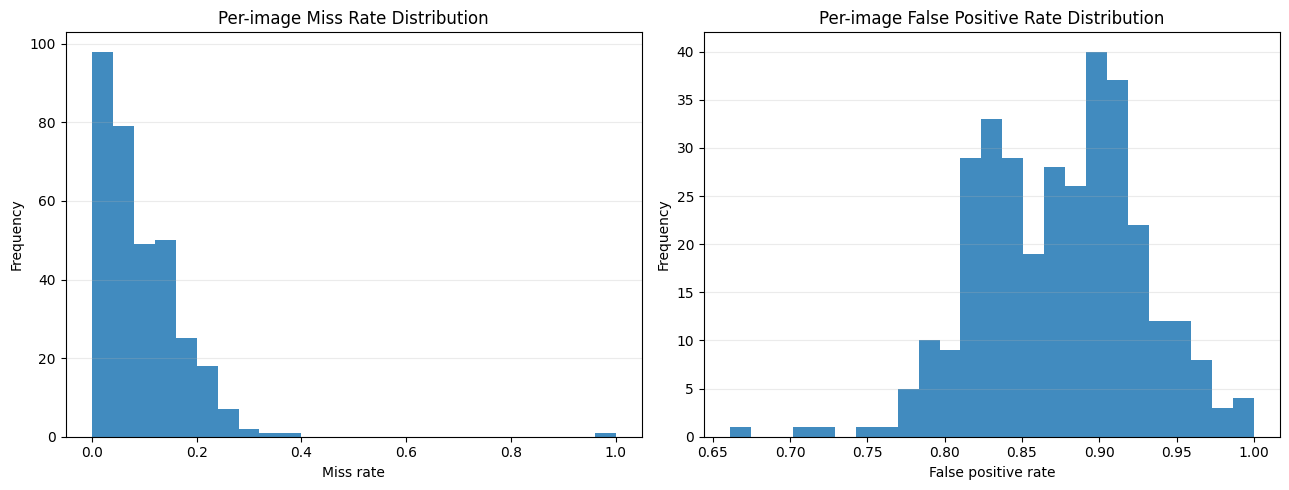

In [18]:
# Cell 6: overall detection summary (miss rate and false positive rate)
if len(image_records) == 0:
    raise ValueError('No image records. Run Cell 5 first.')

img_miss = np.array([r['miss_rate'] for r in image_records], dtype=float)
img_fp = np.array([r['false_positive_rate'] for r in image_records], dtype=float)
num_gt_arr = np.array([r['num_gt'] for r in image_records], dtype=int)
num_pred_arr = np.array([r['num_pred'] for r in image_records], dtype=int)

total_tp = int(np.sum([r['tp'] for r in image_records]))
total_fp = int(np.sum([r['fp'] for r in image_records]))
total_fn = int(np.sum([r['fn'] for r in image_records]))

global_precision = total_tp / max(1, (total_tp + total_fp))
global_recall = total_tp / max(1, (total_tp + total_fn))
global_miss = total_fn / max(1, (total_tp + total_fn))

print('Overall detection summary')
print(f'- Images analyzed: {len(image_records)}')
print(f'- Total GT objects: {int(np.sum(num_gt_arr))}')
print(f'- Total predicted objects: {int(np.sum(num_pred_arr))}')
print(f'- TP: {total_tp}, FP: {total_fp}, FN: {total_fn}')
print(f'- Precision: {global_precision:.4f}')
print(f'- Recall: {global_recall:.4f}')
print(f'- Miss rate (global FN / GT): {global_miss:.4f}')
print(f'- Mean per-image miss rate: {np.mean(img_miss):.4f}')
print(f'- Mean per-image false positive rate: {np.mean(img_fp):.4f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].hist(img_miss, bins=25, alpha=0.85)
ax[0].set_title('Per-image Miss Rate Distribution')
ax[0].set_xlabel('Miss rate')
ax[0].set_ylabel('Frequency')
ax[0].grid(axis='y', alpha=0.25)

ax[1].hist(img_fp, bins=25, alpha=0.85)
ax[1].set_title('Per-image False Positive Rate Distribution')
ax[1].set_xlabel('False positive rate')
ax[1].set_ylabel('Frequency')
ax[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

Miss rate by object size quantile (Q1 smallest -> Q5 largest):
- Q1: 0.3564
- Q2: 0.0735
- Q3: 0.0224
- Q4: 0.0142
- Q5: 0.0110


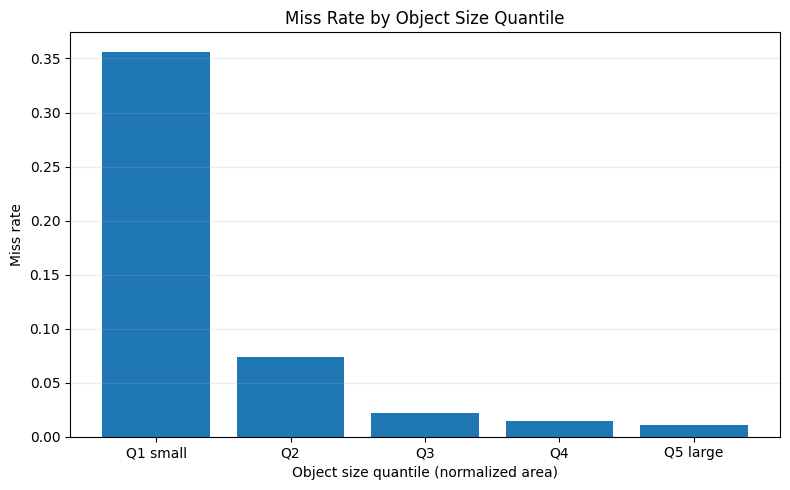

In [19]:
# Cell 7: does model miss small objects more often?
if len(object_records) == 0:
    raise ValueError('No object records. Run Cell 5 first.')

obj_area = np.array([o['gt_area'] for o in object_records], dtype=float)
obj_missed = np.array([1.0 if o['missed'] else 0.0 for o in object_records], dtype=float)

q = np.quantile(obj_area, [0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
for i in range(1, len(q)):
    if q[i] <= q[i - 1]:
        q[i] = q[i - 1] + 1e-12
size_bins = np.digitize(obj_area, q[1:-1], right=True)
miss_rate_by_bin = [float(np.mean(obj_missed[size_bins == i])) if np.any(size_bins == i) else np.nan for i in range(5)]

print('Miss rate by object size quantile (Q1 smallest -> Q5 largest):')
for i, v in enumerate(miss_rate_by_bin, start=1):
    print(f'- Q{i}: {v:.4f}')

plt.figure(figsize=(8, 5))
plt.bar(['Q1 small', 'Q2', 'Q3', 'Q4', 'Q5 large'], miss_rate_by_bin)
plt.xlabel('Object size quantile (normalized area)')
plt.ylabel('Miss rate')
plt.title('Miss Rate by Object Size Quantile')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

Mean miss/FP by brightness quartile (Q1 darkest -> Q4 brightest):
- Q1: miss=0.0860, fp=0.8644
- Q2: miss=0.0948, fp=0.8730
- Q3: miss=0.0879, fp=0.8844
- Q4: miss=0.0978, fp=0.8746


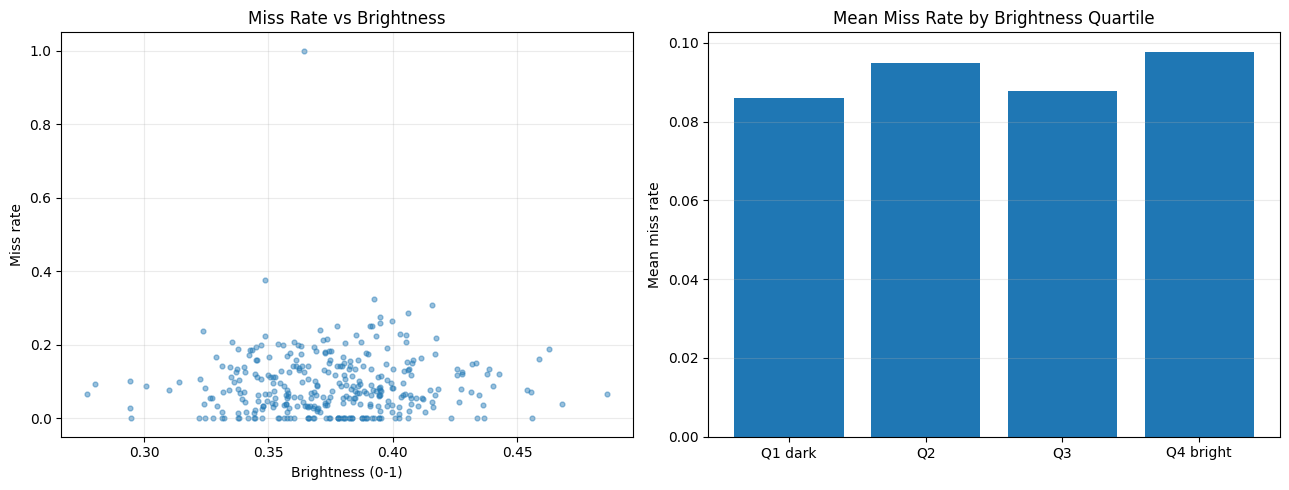

In [20]:
# Cell 8: lighting analysis (brightness vs miss/FP)
brightness = np.array([r['brightness'] for r in image_records], dtype=float)
miss = np.array([r['miss_rate'] for r in image_records], dtype=float)
fp = np.array([r['false_positive_rate'] for r in image_records], dtype=float)

bq = np.quantile(brightness, [0.0, 0.25, 0.5, 0.75, 1.0])
for i in range(1, len(bq)):
    if bq[i] <= bq[i - 1]:
        bq[i] = bq[i - 1] + 1e-12
buckets = np.digitize(brightness, bq[1:-1], right=True)

miss_by_light = [float(np.mean(miss[buckets == i])) if np.any(buckets == i) else np.nan for i in range(4)]
fp_by_light = [float(np.mean(fp[buckets == i])) if np.any(buckets == i) else np.nan for i in range(4)]

print('Mean miss/FP by brightness quartile (Q1 darkest -> Q4 brightest):')
for i in range(4):
    print(f'- Q{i+1}: miss={miss_by_light[i]:.4f}, fp={fp_by_light[i]:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(brightness, miss, s=12, alpha=0.45)
ax[0].set_xlabel('Brightness (0-1)')
ax[0].set_ylabel('Miss rate')
ax[0].set_title('Miss Rate vs Brightness')
ax[0].grid(alpha=0.25)

ax[1].bar(['Q1 dark', 'Q2', 'Q3', 'Q4 bright'], miss_by_light)
ax[1].set_ylabel('Mean miss rate')
ax[1].set_title('Mean Miss Rate by Brightness Quartile')
ax[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

Occlusion diagnostics
- Mean miss rate (low occlusion images): 0.0869
- Mean miss rate (high occlusion images): 0.1034
- Object miss rate (low overlap): 0.0964
- Object miss rate (medium overlap): 0.0813
- Object miss rate (high overlap): 0.2059


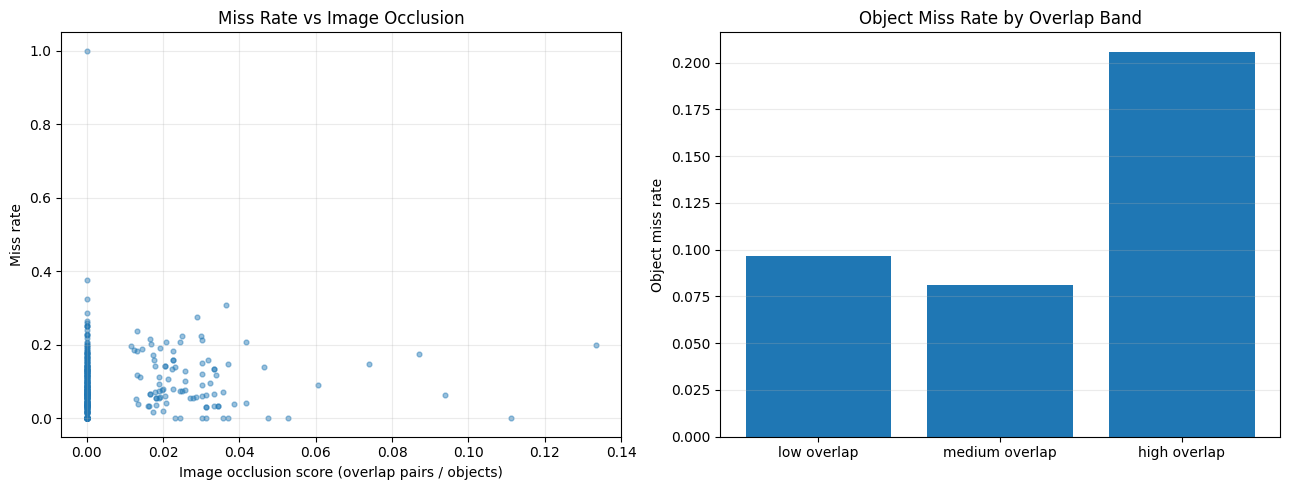

In [21]:
# Cell 9: occlusion analysis
occlusion_img = np.array([r['occlusion_pair_norm'] for r in image_records], dtype=float)
miss = np.array([r['miss_rate'] for r in image_records], dtype=float)

oq = np.quantile(occlusion_img, [0.0, 0.5, 1.0])
if oq[1] <= oq[0]:
    oq[1] = oq[0] + 1e-12
if oq[2] <= oq[1]:
    oq[2] = oq[1] + 1e-12
occ_bin = np.digitize(occlusion_img, oq[1:-1], right=True)

miss_low_occ = float(np.mean(miss[occ_bin == 0])) if np.any(occ_bin == 0) else np.nan
miss_high_occ = float(np.mean(miss[occ_bin == 1])) if np.any(occ_bin == 1) else np.nan

obj_overlap = np.array([o['max_gt_overlap'] for o in object_records], dtype=float)
obj_missed = np.array([1.0 if o['missed'] else 0.0 for o in object_records], dtype=float)

# Object-level overlap bands
bands = [0.0, 0.1, 0.3, 1.01]
labels = ['low overlap', 'medium overlap', 'high overlap']
obj_band = np.digitize(obj_overlap, bands[1:-1], right=False)
miss_by_overlap_band = [
    float(np.mean(obj_missed[obj_band == i])) if np.any(obj_band == i) else np.nan
    for i in range(3)
]

print('Occlusion diagnostics')
print(f'- Mean miss rate (low occlusion images): {miss_low_occ:.4f}')
print(f'- Mean miss rate (high occlusion images): {miss_high_occ:.4f}')
for name, mr in zip(labels, miss_by_overlap_band):
    print(f'- Object miss rate ({name}): {mr:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(occlusion_img, miss, s=12, alpha=0.45)
ax[0].set_xlabel('Image occlusion score (overlap pairs / objects)')
ax[0].set_ylabel('Miss rate')
ax[0].set_title('Miss Rate vs Image Occlusion')
ax[0].grid(alpha=0.25)

ax[1].bar(labels, miss_by_overlap_band)
ax[1].set_ylabel('Object miss rate')
ax[1].set_title('Object Miss Rate by Overlap Band')
ax[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

In [22]:
# Cell 10: inspect worst miss-rate images
top_k = 15
sorted_worst = sorted(image_records, key=lambda r: r['miss_rate'], reverse=True)[:top_k]

print(f'Top {top_k} worst miss-rate images:')
for i, r in enumerate(sorted_worst, start=1):
    print(
        f"{i:2d}. miss={r['miss_rate']:.4f} | fp={r['false_positive_rate']:.4f} | "
        f"gt={r['num_gt']:3d} | pred={r['num_pred']:3d} | "
        f"bright={r['brightness']:.3f} | occ={r['occlusion_pair_norm']:.3f} | {r['image_path']}"
    )

Top 15 worst miss-rate images:
 1. miss=1.0000 | fp=1.0000 | gt=  1 | pred=119 | bright=0.364 | occ=0.000 | /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/test/images/dataset2_back_900.png
 2. miss=0.3750 | fp=0.9515 | gt=  8 | pred=103 | bright=0.349 | occ=0.000 | /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/test/images/dataset2_back_60.png
 3. miss=0.3250 | fp=0.8907 | gt= 40 | pred=247 | bright=0.392 | occ=0.000 | /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/test/images/dataset1_front_271.png
 4. miss=0.3091 | fp=0.8265 | gt= 55 | pred=219 | bright=0.416 | occ=0.036 | /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/test/images/dataset3_back_990.png
 5. miss=0.2857 | fp=0.8750 | gt= 35 | pred=200 | bright=0.406 | occ=0.000 | /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/test/images/dataset3_back_93